### Extinction model: Nogueras-Lara et al. (2020)

Stars around the galactic center region are strongly affected by dust
extinction. Extinction laws around the Galactic center region are different from those in other directions. Ordinary extinction laws cannot reproduce the extinctions measured around the Galactic center region. The extinction law around the galactic center was measured by [Nogueras-Lara et al. (2020)][1] based on the GALACTICNUCLEUS survey. The estimated extinction law is much steeper than a typical extinction
law calibrated in several sight lines in the Milky way and local galaxies.

`jasmine_toolkit` provides a modified extinction law that can mimic the amount of extinction measured in Nogueras-Lara et al. (2020). We slightly modified the extinction model provided [Fitzpatrick et al. (2019)][2] to fit the JHKs extinction law measured by Nogueras-Lara et al. (2020).

[1]: https://ui.adsabs.harvard.edu/abs/2020A%26A...641A.141N/abstract
[2]: https://ui.adsabs.harvard.edu/abs/2019ApJ...886..108F/abstract


In [1]:
import matplotlib.pyplot as plt
import astropy.units as u
import numpy as np

We import the `NL20` model provided by `jasmine_toolkit.extinction`. We also import the `F19` model from `dust_extinction` for comparison.

In [2]:
from jasmine_toolkit.extinction import NL20
from dust_extinction.parameter_averages import F19

model_NL20 = NL20()
model_F19 = F19()

We compare the extinction $A_\lambda$ values between two models, `A19` (Fitzpatrick et al., 2019) and `A20` (Nogueras-Lara et al., 2020).

In [3]:
A19 = lambda l: -2.5 * np.log10(model_F19.extinguish(l, Av=10))
A20 = lambda l: model_NL20.extinction(l, 10)

F19 and NL20 models are illustrated below. The blue crosses and dashed line show the extinction of Fitzpatrick et al. (2019) with $R_V = 3.1$. The orange circles indicate the near-infrared extinction values measured by Nogueras-Lara et al. (2020). NL20 model, a modified F19 model, is shown by the orange dot-dashed line. NL20 model well reproduce the extinction by Nogueras-Lara et al. (2020).

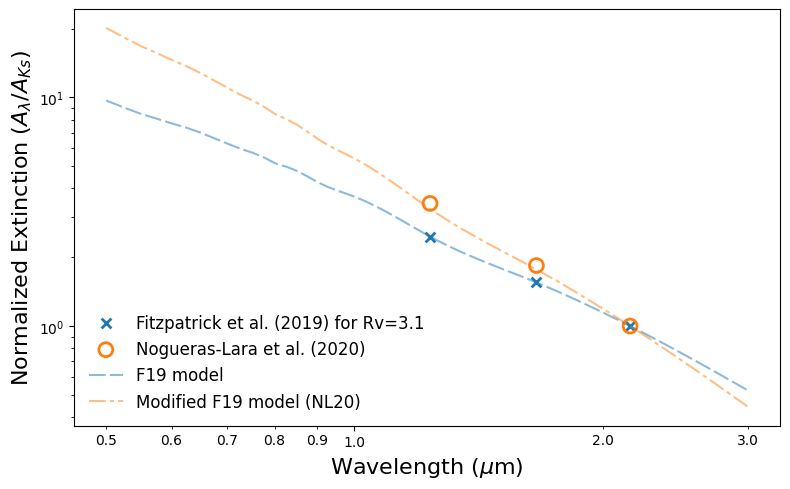

In [4]:
l = np.linspace(0.5, 3, 100) * u.um
jhk = np.array([1.235, 1.662, 2.159]) * u.um

fig, ax = plt.subplots(
    figsize=(8, 5), facecolor='w')

ax.scatter(
    jhk,
    [A19(jhk[0]) / A19(jhk[2]), A19(jhk[1]) / A19(jhk[2]), 1.0],
    s=50, marker='x', lw=2, color='C0',
    label=f'Fitzpatrick et al. (2019) for Rv={model_F19.Rv.value}')
ax.scatter(
    jhk,
    [3.44, 1.84, 1.0],
    s=100, marker='o', lw=2, facecolor='none', edgecolor='C1',
    label='Nogueras-Lara et al. (2020)')

ax.plot(
    l, A19(l) / A19(jhk[2]),
    color='C0', dashes=(8, 2), alpha=0.5,
    label='F19 model')
ax.plot(
    l, A20(l) / A20(jhk[2]),
    color='C1', dashes=(8, 2, 2, 2), alpha=0.5,
    label='Modified F19 model (NL20)')

ax.set_xlabel(
    r'Wavelength ($\mu$m)', fontsize=16)
ax.set_ylabel(
    r'Normalized Extinction ($A_\lambda/A_{Ks}$)', fontsize=16)
ax.set_xscale('log')
ax.set_yscale('log')
ax.xaxis.set_major_formatter('{x:.1f}')
ax.xaxis.set_minor_formatter('{x:.1f}')
ax.legend(frameon=False, fontsize=12, loc='lower left')

fig.tight_layout()
plt.show()